# 03 — Training runner

This notebook runs training from a selected config. The notebook itself
is shared for all experiments; the chosen config string selects the
run.

If you want parallel work, open multiple Colab sessions on the same
notebook and each session picks a different `RUN` value.


## Environment setup

This notebook is not one run per file. Instead:

- one notebook = one runner
- one config = one experiment
- different people can use the same notebook with different config values

In Colab, the notebook runs on a remote VM. If the repo is not already
available there, this notebook will clone it from GitHub. It also stages
data from the shared Drive archive into `/content/data` using the
paths defined in `configs/paths.yaml`.


In [2]:
from pathlib import Path
import subprocess
import sys
import torch
import zipfile

REPO_URL = "https://github.com/FilippoIsoni/sharp-har.git"

# Locate or clone the repository root containing the sharp_har package.
# In Colab, the notebook may run from a temporary working directory.
cwd = Path.cwd().resolve()
if (cwd / "sharp_har").exists():
    REPO_DIR = cwd
elif (cwd.parent / "sharp_har").exists():
    REPO_DIR = cwd.parent
elif (cwd.parent.parent / "sharp_har").exists():
    REPO_DIR = cwd.parent.parent
else:
    REPO_DIR = Path("/content/sharp-har")
    if not REPO_DIR.exists():
        REPO_DIR.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

sys.path.insert(0, str(REPO_DIR))

from google.colab import drive
from sharp_har.train import train_run
from sharp_har.utils import read_yaml

paths_cfg = read_yaml(REPO_DIR / "configs" / "paths.yaml")
drive_root = Path(paths_cfg["drive_root"])
stage_dir = Path(paths_cfg["stage_dir"])
CKPT_ROOT = Path(paths_cfg["ckpt_root"])

# Mount Drive and stage the zip archives if needed.
# This follows the project convention in 00_setup_smoke.ipynb.
if not (stage_dir.exists() and any(stage_dir.rglob("*.txt"))):
    drive.mount("/content/drive")
    stage_dir.mkdir(parents=True, exist_ok=True)
    for zip_name in paths_cfg["zips"]:
        src = drive_root / zip_name
        dst = Path("/content") / zip_name
        print(f"copying {src} -> {dst}")
        subprocess.run(["cp", str(src), str(dst)], check=True)
        with zipfile.ZipFile(dst) as zf:
            zf.extractall(stage_dir)

print("Repo dir:", REPO_DIR)
print("sharp_har exists:", (REPO_DIR / "sharp_har").exists())
print("GPU available:", torch.cuda.is_available())
print("Stage dir:", stage_dir)
print("Checkpoint root:", CKPT_ROOT)


Mounted at /content/drive
copying /content/drive/MyDrive/DATASET_SHARP/doppler_traces.zip -> /content/doppler_traces.zip
copying /content/drive/MyDrive/DATASET_SHARP/doppler_traces_S4_S5.zip -> /content/doppler_traces_S4_S5.zip
Repo dir: /content/sharp-har
sharp_har exists: True
GPU available: False
Stage dir: /content/data
Checkpoint root: /content/drive/MyDrive/sharp_har_runs


## Load config and launch the run

Choose one config stem below and run the cell. The config name
determines which experiment is executed.


In [3]:
RUN = "c0_sharp"  # choose one of c0_sharp, c1_ce, c2_grl, c3_supcon, c4_supcon_grl
cfg = read_yaml(REPO_DIR / "configs" / f"{RUN}.yaml")

print("Selected run:", RUN)
print("Config summary:")
print(cfg)

out = train_run(cfg, stage_dir=stage_dir, ckpt_dir=CKPT_ROOT, repo_dir=REPO_DIR)
print("Train run finished:", out)


2026-07-16 13:36:49,874 [INFO] sharp_har.data: train: excluding 7 trace(s) with activities outside the class list ['E', 'J', 'L', 'R', 'W']: ['S1a_C', 'S1a_H', 'S1a_S', 'S1b_H', 'S1c_C', 'S1c_H', 'S1c_S']
2026-07-16 13:36:49,921 [INFO] sharp_har.data: train: 15 traces, 9180 (window, antenna) samples (win=340, stride=100)
2026-07-16 13:36:49,931 [INFO] sharp_har.data: val: excluding 2 trace(s) with activities outside the class list ['E', 'J', 'L', 'R', 'W']: ['S1b_C', 'S1b_S']
2026-07-16 13:36:49,938 [INFO] sharp_har.data: val: 3 traces, 540 (window, antenna) samples (win=340, stride=340)


Selected run: c0_sharp
Config summary:
{'name': 'C0', 'protocol': 'P1-sharp', 'split_file': 'splits/p1_sharp.json', 'backbone': 'sharp_like', 'd_enc': 256, 'n_att': 5, 'labels': ['E', 'J', 'L', 'R', 'W'], 'loss': {'type': 'ce', 'label_smoothing': 0.0}, 'adversary': {'type': None, 'target': None, 'lambda_max': None, 'beta': None}, 'optim': {'name': 'adam', 'lr': 0.0001, 'wd': 0.0, 'warmup_epochs': 0, 'scheduler': 'none'}, 'train': {'epoch_steps': 400, 'max_epochs': 60, 'batch_size': 32, 'sampler': 'uniform', 'augment': False, 'amp': True, 'grad_clip': 1.0}, 'eval': {'select_metric': 'val_macro_f1', 'patience': 10}}


2026-07-16 13:40:46,417 [INFO] sharp_har.train: C0 epoch 1/60: loss 1.2538, val macro-F1 0.4116, 0.563 s/step
2026-07-16 13:44:30,317 [INFO] sharp_har.train: C0 epoch 2/60: loss 1.0571, val macro-F1 0.1643, 0.550 s/step
2026-07-16 13:48:19,847 [INFO] sharp_har.train: C0 epoch 3/60: loss 1.0140, val macro-F1 0.2826, 0.564 s/step
2026-07-16 13:52:02,976 [INFO] sharp_har.train: C0 epoch 4/60: loss 0.9873, val macro-F1 0.2745, 0.549 s/step
2026-07-16 13:55:49,632 [INFO] sharp_har.train: C0 epoch 5/60: loss 0.9626, val macro-F1 0.3011, 0.558 s/step
2026-07-16 13:59:43,642 [INFO] sharp_har.train: C0 epoch 6/60: loss 0.9476, val macro-F1 0.6674, 0.575 s/step
2026-07-16 14:03:35,773 [INFO] sharp_har.train: C0 epoch 7/60: loss 0.9343, val macro-F1 0.3358, 0.569 s/step
2026-07-16 14:07:20,627 [INFO] sharp_har.train: C0 epoch 8/60: loss 0.9224, val macro-F1 0.3513, 0.553 s/step
2026-07-16 14:11:17,287 [INFO] sharp_har.train: C0 epoch 9/60: loss 0.9094, val macro-F1 0.4510, 0.580 s/step
2026-07-16

KeyboardInterrupt: 

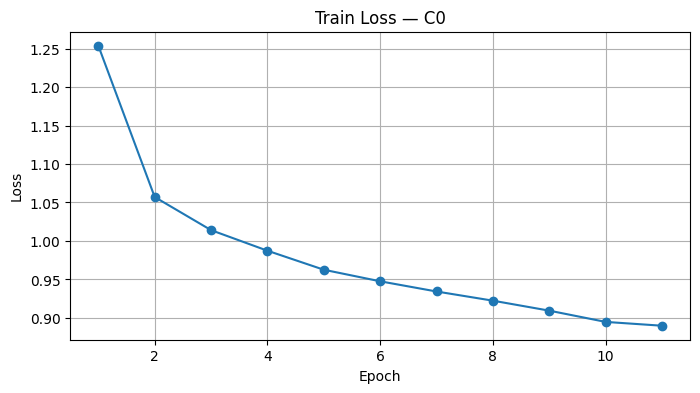

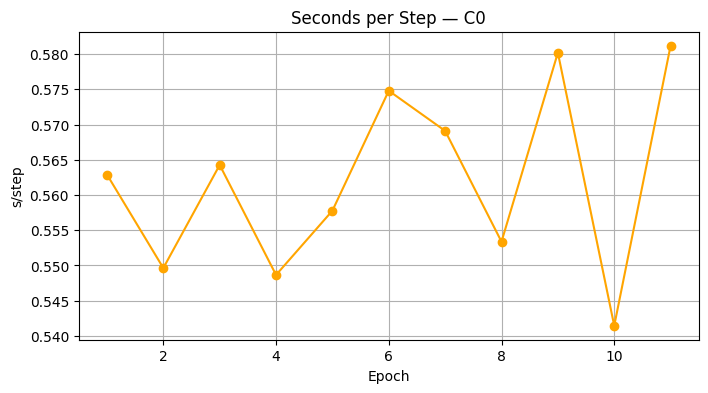

Grafici generati per C0


In [6]:
# GRAFICI
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def plot_run_metrics(run_dir: Path):
    hist_path = run_dir / "history.csv"
    if not hist_path.exists():
        print("history.csv non trovato:", hist_path)
        return

    # Carica la history
    hist = pd.read_csv(hist_path)

    # --- LOSS ---
    plt.figure(figsize=(8, 4))
    plt.plot(hist["epoch"], hist["train_loss"], marker="o")
    plt.title(f"Train Loss — {run_dir.name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

    # --- VAL MACRO-F1 (solo CE) ---
    # #if "val_macro_f1" in hist.columns:
    #     plt.figure(figsize=(8, 4))
    #     plt.plot(hist["epoch"], hist["val_macro_f1"], marker="o", color="green")
    #     plt.title(f"Val Macro-F1 — {run_dir.name}")
    #     plt.xlabel("Epoch")
    #     plt.ylabel("Macro-F1")
    #     plt.grid(True)
    #     plt.show()

    # # --- AR-SET ACCURACY (solo GRL) ---
    # if "arset_train_acc" in hist.columns:
    #     plt.figure(figsize=(8, 4))
    #     plt.plot(hist["epoch"], hist["arset_train_acc"], marker="o", color="red")
    #     plt.title(f"AR-set Train Accuracy — {run_dir.name}")
    #     plt.xlabel("Epoch")
    #     plt.ylabel("Accuracy")
    #     plt.grid(True)
    #     plt.show()

    # # --- LEARNING RATE ---
    # plt.figure(figsize=(8, 4))
    # plt.plot(hist["epoch"], hist["lr"], marker="o", color="purple")
    # plt.title(f"Learning Rate — {run_dir.name}")
    # plt.xlabel("Epoch")
    # plt.ylabel("LR")
    # plt.grid(True)
    #plt.show()

    # --- SECONDS PER STEP ---
    plt.figure(figsize=(8, 4))
    plt.plot(hist["epoch"], hist["s_per_step"], marker="o", color="orange")
    plt.title(f"Seconds per Step — {run_dir.name}")
    plt.xlabel("Epoch")
    plt.ylabel("s/step")
    plt.grid(True)
    plt.show()

    print(f"Grafici generati per {run_dir.name}")


run_dir = CKPT_ROOT / cfg["name"]
plot_run_metrics(run_dir)
